<a href="https://colab.research.google.com/github/nehakatk-ops/bbc-text-vectorizer/blob/main/MyProject02_Count_Vectorizer_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
style.use('dark_background')
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression

import nltk
from nltk import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.corpus import wordnet

# Data for nltk

In [ ]:
nltk.download("wordnet") # It helps find conceptual relationship between the words
nltk.download('punkt') # It is pretrained tokenizer for English
nltk.download('averaged_perceptron_tagger') # Pretrained english POS Tagger
nltk.download('omw-1.4') # Open multilingual wordnet. The goal is to make it easy to use wordnets in multiple languages.

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

# Mount the Drive and set the path

In [ ]:
%cd /content/drive/MyDrive

[Errno 2] No such file or directory: '/content/drive/MyDrive'
/content


# Read the dataset

In [ ]:
df = pd.read_csv('bbc-text (1).csv')
df.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [ ]:
import pandas as pd

# Assuming 'bbc-text.csv' has been uploaded to the current session storage
df = pd.read_csv('bbc-text (1).csv')

# Display the first few rows to confirm it's loaded correctly
display(df.head())

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [ ]:
df.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [ ]:
df.shape

(2225, 2)

# Transforming Categories into integers

In [ ]:
df.category.unique()

array(['tech', 'business', 'sport', 'entertainment', 'politics'],
      dtype=object)

In [ ]:
df.category.replace(to_replace = 'tech', value = 0, inplace = True)
df.category.replace(to_replace = 'business', value = 1, inplace = True)
df.category.replace(to_replace = 'sport', value = 2, inplace = True)
df.category.replace(to_replace = 'entertainment', value = 3, inplace = True)
df.category.replace(to_replace = 'politics', value = 4, inplace = True)


/tmp/ipykernel_878/3914593880.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.category.replace(to_replace = 'tech', value = 0, inplace = True)
/tmp/ipykernel_878/3914593880.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

In [ ]:
df.head()

,category,text
0,0,tv future in the hands of viewers with home th...
1,1,worldcom boss left books alone former worldc...
2,2,tigers wary of farrell gamble leicester say ...
3,2,yeading face newcastle in fa cup premiership s...
4,3,ocean s twelve raids box office ocean s twelve...


# Extract Feature and Labels

In [ ]:
features = df['text']
labels = df['category']

# Check if the dataset is balanced

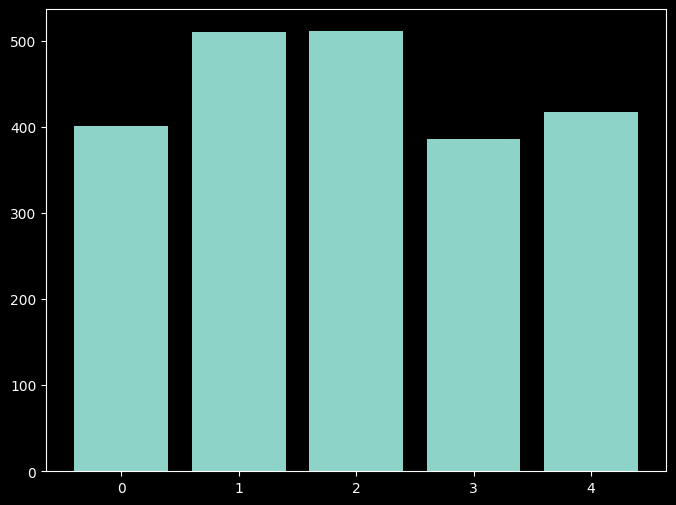

In [ ]:
plt.figure(figsize = (8,6))
x, y = np.unique(labels, return_counts=True)
plt.bar(x, y, align='center')
plt.gca().set_xticks(x)
plt.show()

# Data Splitting

In [ ]:
train_data, test_data, train_labels, test_labels = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=42
)

In [ ]:
train_data.shape

(1780,)

In [ ]:
train_data[0]

'tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert panel which gathered at the annual consumer electronics show in las vegas to discuss how these new technologies will impact one of our favourite pastimes. with the us leading the trend  programmes and other content will be delivered to viewers via home networks  through cable  satellite  telecoms companies  and broadband service providers to front rooms and portable devices.  one of the most talked-about technologies of ces has been digital and personal video recorders (dvr and pvr). these set-top boxes  like the us s tivo and the uk s sky+ system  allow people to record  store  play  pause and forward wind tv programmes when they want.  essentially  the technology allows for much more personalised tv. they are also being built-in to high

In [ ]:
train_labels[0]

np.int64(0)

# Extract Text Features Using Count Vectorizer

In [ ]:
vectorizer = TfidfVectorizer()

Xtrain = vectorizer.fit_transform(train_data)
Xtest = vectorizer.transform(test_data)

In [ ]:
Xtrain = vectorizer.fit_transform(train_data)
Xtest = vectorizer.transform(test_data)

# Get information about Xtrain

In [ ]:
Xtrain.shape # This is document to word OR document to term Matrix

(1780, 26621)

In [ ]:
Xtrain  # Unusual w.r.to ML because it has more columns than rows. Since we have just converted text into number thereforefore
        # we get the sparse matrix.

<1780x26621 sparse matrix of type '<class 'numpy.int64'>'
	with 359258 stored elements in Compressed Sparse Row format>

# Find the percentage of non-zero elements in Xtrain

In [ ]:
(Xtrain != 0).sum()

np.int64(359258)

In [ ]:
non_zero_elements = ((Xtrain != 0).sum() / np.prod(Xtrain.shape)) *100

In [ ]:
print("Percentage of non-zero elements in Xtrain : %2.2f" % (non_zero_elements))

Percentage of non-zero elements in Xtrain : 0.76


# Instantiate, train and test on Naive Baye's Model

In [ ]:
model = MultinomialNB()
model.fit(Xtrain, train_labels)
print("Training Accuracy : %2.2f" % (model.score(Xtrain, train_labels)))
print("Testing Accuracy : %2.2f" % (model.score(Xtest, test_labels)))

Training Accuracy : 0.98
Testing Accuracy : 0.93


In [ ]:
#Logistic Regression Model

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(Xtrain, train_labels)
print("Training Accuracy:", lr_model.score(Xtrain, train_labels))
print("Testing Accuracy:", lr_model.score(Xtest, test_labels))

Training Accuracy: 0.994943820224719
Testing Accuracy: 0.9617977528089887


# Repeat Experiment Using Stopwards because previously we used default values

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english')
Xtrain = vectorizer.fit_transform(train_data)
Xtest = vectorizer.transform(test_data)
model = MultinomialNB()
model.fit(Xtrain, train_labels)
print("Training Accuracy : %2.2f" % (model.score(Xtrain, train_labels)))
print("Testing Accuracy : %2.2f" % (model.score(Xtest, test_labels)))

Training Accuracy : 0.99
Testing Accuracy : 0.96


In [ ]:
#logistic Regression for Stopwords
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(Xtrain, train_labels)
print("Training Accuracy:", lr_model.score(Xtrain, train_labels))
print("Testing Accuracy:", lr_model.score(Xtest, test_labels))

Training Accuracy: 0.994943820224719
Testing Accuracy: 0.9617977528089887


# Repeat Experiment with Lemmatization

In [ ]:
def get_wordnet_pos(treebank_tag):
  if treebank_tag.startswith('J'):
    return wordnet.ADJ
  elif treebank_tag.startswith('V'):
    return wordnet.VERB
  elif treebank_tag.startswith('N'):
    return wordnet.NOUN
  elif treebank_tag.startswith('R'):
    return wordnet.ADV
  else:
    return wordnet.NOUN

# Create a Tokenizer class for Lemmatization

In [ ]:
class LemmaTokenizer:
  def __init__(self):
    self.wnl = WordNetLemmatizer()
  def __call__(self, doc):
    tokens = word_tokenize(doc) # word_tokenize is a function in NLTK
    words_and_tags = nltk.pos_tag(tokens)
    return [self.wnl.lemmatize(word, pos=get_wordnet_pos(tag)) \
            for word, tag in words_and_tags]

# Using Lemmatization

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
vectorizer = TfidfVectorizer(tokenizer=LemmaTokenizer())
Xtrain = vectorizer.fit_transform(train_data)
Xtest = vectorizer.transform(test_data)
model = MultinomialNB()
model.fit(Xtrain, train_labels)
print("Training Accuracy : %2.2f" % (model.score(Xtrain, train_labels)))
print("Testing Accuracy : %2.2f" % (model.score(Xtest, test_labels)))

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Training Accuracy : 0.98
Testing Accuracy : 0.93


# Repeat Experiment Using Stemming

# Create Tokenization class for Stemming

In [ ]:
class StemTokenizer:
  def __init__(self):
    self.porter = PorterStemmer()
  def __call__(self, doc):
    tokens = word_tokenize(doc)
    return [self.porter.stem(t) for t in tokens]

# Use Stemming

In [ ]:
vectorizer = TfidfVectorizer(tokenizer=StemTokenizer())
Xtrain = vectorizer.fit_transform(train_data)
Xtest = vectorizer.transform(test_data)
model = MultinomialNB()
model.fit(Xtrain, train_labels)
print("Training Accuracy : %2.2f" % (model.score(Xtrain, train_labels)))
print("Testing Accuracy : %2.2f" % (model.score(Xtest, test_labels)))

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Training Accuracy : 0.98
Testing Accuracy : 0.94


In [ ]:
#log regression results
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(Xtrain, train_labels)
print("Training Accuracy:", lr_model.score(Xtrain, train_labels))
print("Testing Accuracy:", lr_model.score(Xtest, test_labels))

Training Accuracy: 0.9960674157303371
Testing Accuracy: 0.9662921348314607


# Repeat Experiment Using simple splitting

In [ ]:
def simple_tokenizer(s):
  return s.split()

In [ ]:
vectorizer = TfidfVectorizer(tokenizer=simple_tokenizer)
Xtrain = vectorizer.fit_transform(train_data)
Xtest = vectorizer.transform(test_data)
model = MultinomialNB()
model.fit(Xtrain, train_labels)
print("Training Accuracy : %2.2f" % (model.score(Xtrain, train_labels)))
print("Testing Accuracy : %2.2f" % (model.score(Xtest, test_labels)))

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Training Accuracy : 0.98
Testing Accuracy : 0.93


In [ ]:
#Log regression again
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(Xtrain, train_labels)
print("Training Accuracy:", lr_model.score(Xtrain, train_labels))
print("Testing Accuracy:", lr_model.score(Xtest, test_labels))

Training Accuracy: 0.994943820224719
Testing Accuracy: 0.9617977528089887


The TF-IDF vectorization was applied through the BBC text dataset by using different preprocessing techniques such as stopword removal, lemmatization, stemming and simple tokenization. Both Naive Bayes and Logisitc Regression models were trained and evaluated. Overall the results show that Logistic Regression outperformed Naive Bayes in all experiemnts. However, the best performance was achieved using TF-IDF with lemmatization and Logistic Regression which in all codes applied outperformed Naive Bayes. THe result of testing accuracy of lemmatiziation and Logistic regression is 97.08%.